# Task 3: What affects question selection (based on category and level)?

This analysis explores whether prior mistakes influence the agent's question selection behavior. Specifically, we want to know if the agent changes its strategy after getting a question wrong.

We investigate this one by one for both `tool` runs and `control` runs. We pair them by Seed and Turn to easily compare how the gamified constraints or base LLM behave differently after a failure.

In [1]:
import json
import pandas as pd
from IPython.display import display, HTML

with open('../scripts/parsed_task3.json', 'r') as f:
    task3_data = json.load(f)

df_task3 = pd.DataFrame(task3_data)

if df_task3.empty:
    print("No post-mistake actions found.")
else:
    # Sort logically so we can compare seed by seed and turn by turn
    df_task3.sort_values(by=['seed', 'chamber_after_mistake', 'mode'], inplace=True)
    
    html_str = """<style>
        .mistake-box { border: 1px solid #ddd; padding: 15px; margin-bottom: 20px; border-radius: 6px; background-color: #fff; }
        .mode-tool { border-left: 5px solid #2ecc71; }
        .mode-control { border-left: 5px solid #3498db; }
        .header-bar { display: flex; justify-content: space-between; border-bottom: 1px solid #eee; padding-bottom: 10px; margin-bottom: 15px; }
        .reason-str { background-color: #f8f9fa; padding: 10px; border-radius: 4px; font-style: italic; color: #555; }
        .action-str { font-weight: bold; color: #d35400; }
        .doors-list { margin-top: 5px; list-style-type: none; padding-left: 0; }
        .doors-list li { margin-bottom: 4px; padding: 4px; background-color: #fdfdfd; border: 1px solid #f0f0f0; border-radius: 3px; }
    </style>"""
    
    for index, row in df_task3.iterrows():
        mode_class = "mode-tool" if row['mode'] == 'tool' else "mode-control"
        mode_badge = f"<strong style='color: {'#27ae60' if row['mode'] == 'tool' else '#2980b9'}; text-transform: uppercase;'>{row['mode']} MODE</strong>"
        
        doors_html = "".join([f"<li><b>Door {d['door']}</b>: Level {d['level']} &mdash; <span style='color:#666'>{d['category']}</span></li>" for d in row['doors_available']])
        
        html_str += f"""
        <div class='mistake-box {mode_class}'>
            <div class='header-bar'>
                <div style='font-size: 1.1em;'><b>Seed: {row['seed']} | Chamber (Turn): {row['chamber_after_mistake']}</b></div>
                <div>{mode_badge}</div>
            </div>
            
            <div style='margin-bottom: 15px;'>
                <span style='background-color:#ffeaa7; padding:4px 8px; border-radius:4px; font-weight:bold; color:#d63031;'>
                    ⚠️ Prior Mistake: Got a Level {row['mistake_level']} {row['mistake_category']} question wrong
                </span>
            </div>
            
            <div style='display:flex; gap: 20px;'>
                <div style='flex: 1;'>
                    <b>Available Doors in Current Chamber:</b>
                    <ul class='doors-list'>
                        {doors_html}
                    </ul>
                </div>
                <div style='flex: 1.5;'>
                    <div style='margin-bottom: 10px;'>
                        <b>Action Taken:</b> <span class='action-str'>{row['action_taken']}</span>
                    </div>
                    <div>
                        <b>Stated Reasoning:</b>
                        <div class='reason-str'>"{row['reason']}"</div>
                    </div>
                </div>
            </div>
        </div>
        """
        
    display(HTML(html_str))

## 3.1 Aggregate Post-Mistake Selection Behavior

Here we compare the raw behavior.
1. **Control vs Tool:** What category and level do they choose immediately after answering incorrectly?
2. **Tool (Post-Mistake) vs Tool (Overall):** Does the Tool mode explicitly change its category preferences after a mistake compared to its normal baseline distribution?

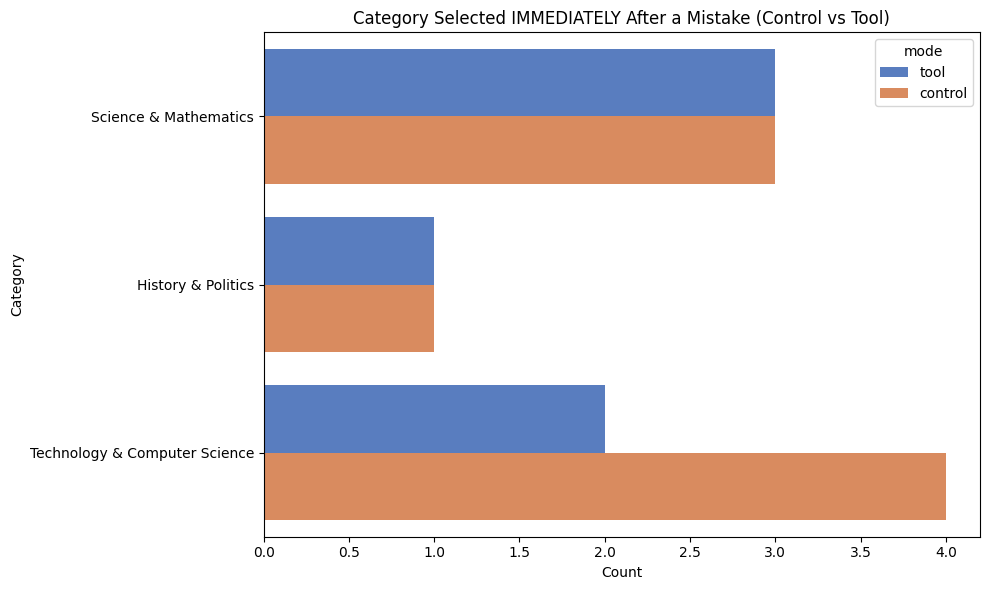

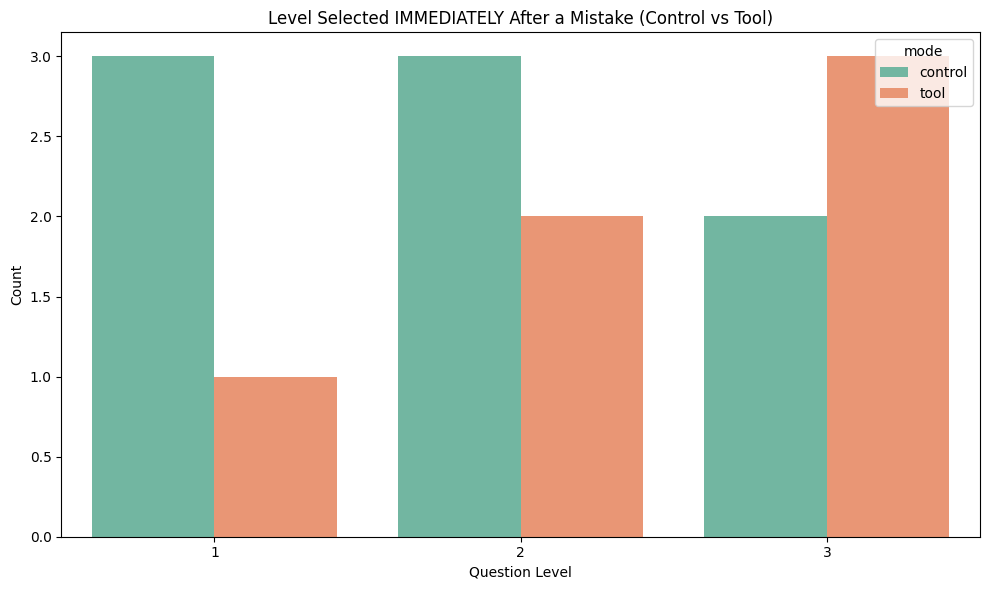

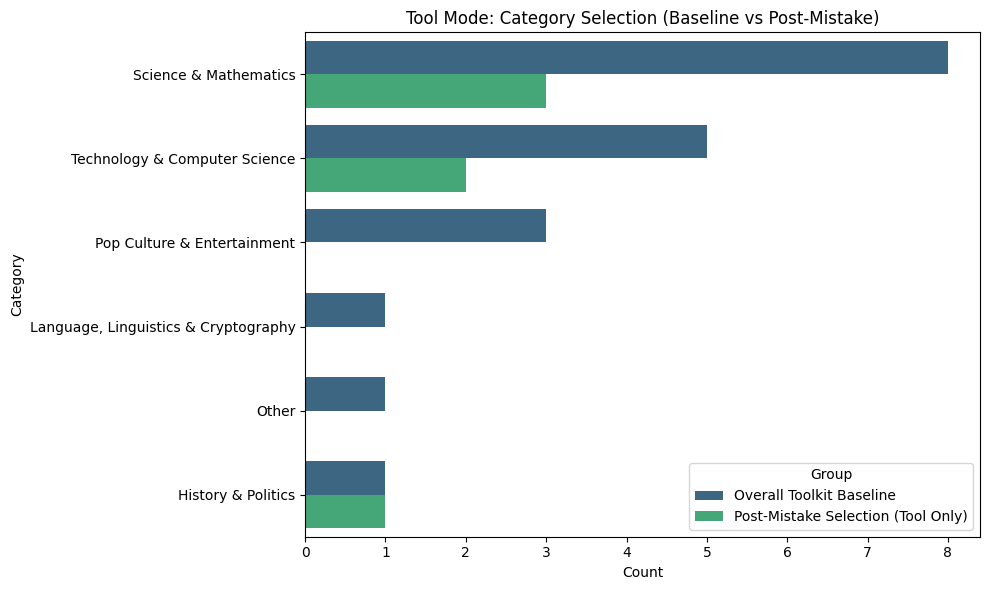

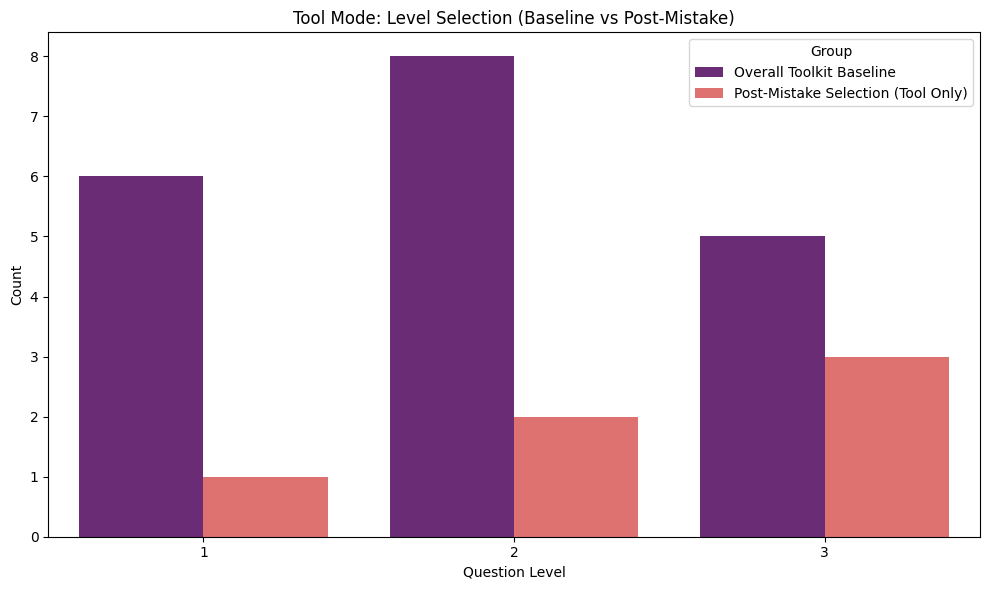

In [4]:
import re
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pandas as pd

# Helper to extract the chosen category and level from strings like "Choose Door -> Geography (L2)"
def extract_choice(action_str):
    if not isinstance(action_str, str): return None, None
    match = re.search(r'->\s*(.+?)\s*\(L(\d+)\)', action_str)
    if match:
        return match.group(1).strip(), int(match.group(2))
    return None, None

# Parse out and drop any events where it didn't strictly choose a door/double-down (e.g., Flee/Reroll)
df_task3['chosen_category'], df_task3['chosen_level'] = zip(*df_task3['action_taken'].map(extract_choice))
df_choices = df_task3.dropna(subset=['chosen_category', 'chosen_level'])

# ==========================================================
# 1. Compare Control vs Tool (Post-Mistake ONLY) - CATEGORY
# ==========================================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df_choices, y='chosen_category', hue='mode', palette='muted')
plt.title('Category Selected IMMEDIATELY After a Mistake (Control vs Tool)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ==========================================================
# 2. Compare Control vs Tool (Post-Mistake ONLY) - LEVEL
# ==========================================================
plt.figure(figsize=(10, 6))
sns.countplot(data=df_choices, x='chosen_level', hue='mode', palette='Set2')
plt.title('Level Selected IMMEDIATELY After a Mistake (Control vs Tool)')
plt.xlabel('Question Level')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# ==========================================================
# Data Prep: Load overall runs for baseline comparisons
# ==========================================================
with open('../scripts/parsed_data.json', 'r') as f:
    all_data = json.load(f)
    
all_tool_categories = []
all_tool_levels = []
for r in all_data:
    if r['mode'] == 'tool':
        for q in r['questions_attempted']:
            all_tool_categories.append(q['category'])
            all_tool_levels.append(int(q['level']))
            
# Baseline Category
df_overall_category = pd.DataFrame(all_tool_categories, columns=['category'])
overall_cat_counts = df_overall_category['category'].value_counts(normalize=False).reset_index()
overall_cat_counts.columns = ['Category', 'Count']
overall_cat_counts['Group'] = 'Overall Toolkit Baseline'

# Baseline Level
df_overall_level = pd.DataFrame(all_tool_levels, columns=['level'])
overall_lvl_counts = df_overall_level['level'].value_counts(normalize=False).reset_index()
overall_lvl_counts.columns = ['Level', 'Count']
overall_lvl_counts['Group'] = 'Overall Toolkit Baseline'

# Post-Mistake Category & Level
df_tool_mistakes = df_choices[df_choices['mode'] == 'tool']

mistake_cat_counts = df_tool_mistakes['chosen_category'].value_counts(normalize=False).reset_index()
mistake_cat_counts.columns = ['Category', 'Count']
mistake_cat_counts['Group'] = 'Post-Mistake Selection (Tool Only)'

mistake_lvl_counts = df_tool_mistakes['chosen_level'].value_counts(normalize=False).reset_index()
mistake_lvl_counts.columns = ['Level', 'Count']
mistake_lvl_counts['Group'] = 'Post-Mistake Selection (Tool Only)'

# ==========================================================
# 3. Tool Mode: Post-Mistake vs Overall Baseline - CATEGORY
# ==========================================================
combined_cat = pd.concat([overall_cat_counts, mistake_cat_counts])

plt.figure(figsize=(10, 6))
sns.barplot(data=combined_cat, y='Category', x='Count', hue='Group', palette='viridis')
plt.title('Tool Mode: Category Selection (Baseline vs Post-Mistake)')
plt.xlabel('Count')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

# ==========================================================
# 4. Tool Mode: Post-Mistake vs Overall Baseline - LEVEL
# ==========================================================
combined_lvl = pd.concat([overall_lvl_counts, mistake_lvl_counts])

plt.figure(figsize=(10, 6))
sns.barplot(data=combined_lvl, x='Level', y='Count', hue='Group', palette='magma')
plt.title('Tool Mode: Level Selection (Baseline vs Post-Mistake)')
plt.ylabel('Count')
plt.xlabel('Question Level')
plt.tight_layout()
plt.show()